In [166]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt

(<Axes: >, <matplotlib.image.AxesImage at 0x207d06b8f50>)

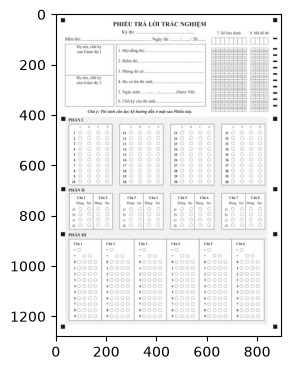

In [167]:
img_root = cv.imread('./data/sample1.jpg', cv.IMREAD_COLOR_BGR)
img = cv.cvtColor(img_root,cv.COLOR_BGR2GRAY)
plt.subplot(121),plt.imshow(img,cmap = 'gray')

(<Axes: >, <matplotlib.image.AxesImage at 0x207d0702990>)

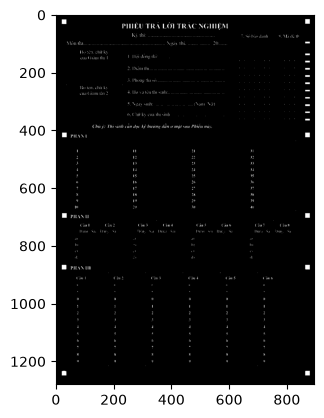

In [168]:
_, thresh = cv.threshold(img, 100, 255, cv.THRESH_BINARY_INV)
plt.subplot(111),plt.imshow(thresh,cmap = 'gray')


In [169]:
contours, _ = cv.findContours(thresh, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

In [170]:
square_candidates = []
for c in contours:
    x,y,w,h = cv.boundingRect(c)
    area = cv.contourArea(c)

    if area < 100 or area > 5000:
        continue

    aspect_ratio = float(w) / h
    if not (0.85 <= aspect_ratio <= 1.15):
        continue

    extent = area / float(w * h)
    if extent < 0.80:
        continue

    M = cv.moments(c)
    if M['m00'] != 0:
        cx = M['m10'] /M['m00']
        cy = M['m01'] /M['m00']
        square_candidates.append({
            "contour": c,
            "bbox":(x,y,w,h),
            "center":(cx,cy),
            "area":area
        })

In [171]:
print(square_candidates)

[{'contour': array([[[ 865, 1233]],

       [[ 864, 1234]],

       [[ 864, 1248]],

       [[ 879, 1248]],

       [[ 879, 1233]]], dtype=int32), 'bbox': (864, 1233, 16, 16), 'center': (871.515961395694, 1240.5159613956941), 'area': 224.5}, {'contour': array([[[  24, 1233]],

       [[  23, 1234]],

       [[  21, 1234]],

       [[  21, 1248]],

       [[  36, 1248]],

       [[  36, 1237]],

       [[  35, 1236]],

       [[  36, 1235]],

       [[  36, 1234]],

       [[  33, 1234]],

       [[  32, 1233]]], dtype=int32), 'bbox': (21, 1233, 16, 16), 'center': (28.44648318042813, 1240.7140672782873), 'area': 218.0}, {'contour': array([[[864, 866]],

       [[864, 880]],

       [[865, 881]],

       [[879, 881]],

       [[879, 866]]], dtype=int32), 'bbox': (864, 866, 16, 16), 'center': (871.515961395694, 873.4840386043059), 'area': 224.5}, {'contour': array([[[ 21, 866]],

       [[ 21, 881]],

       [[ 35, 881]],

       [[ 36, 880]],

       [[ 36, 867]],

       [[ 35, 866]]], 

In [172]:
pts = np.array([c["center"] for c in square_candidates])

sum = pts[:,0] + pts[:,1]
tl = square_candidates[np.argmin(sum)] #top left
br = square_candidates[np.argmax(sum)] # btm right

different = pts[:,0] - pts[:,1]
tr = square_candidates[np.argmax(different)]
bl = square_candidates[np.argmin(different)]

src_corners = {
    "TL":tl,
    "TR":tr,
    "BR":br,
    "BL":bl
}

In [173]:
src_corners

{'TL': {'contour': array([[[21, 16]],
  
         [[21, 31]],
  
         [[22, 31]],
  
         [[23, 30]],
  
         [[24, 31]],
  
         [[36, 31]],
  
         [[36, 16]]], dtype=int32),
  'bbox': (21, 16, 16, 16),
  'center': (28.524553571428573, 23.468005952380953),
  'area': 224.0},
 'TR': {'contour': array([[[864,  15]],
  
         [[864,  30]],
  
         [[879,  30]],
  
         [[879,  15]]], dtype=int32),
  'bbox': (864, 15, 16, 16),
  'center': (871.5, 22.5),
  'area': 225.0},
 'BR': {'contour': array([[[ 865, 1233]],
  
         [[ 864, 1234]],
  
         [[ 864, 1248]],
  
         [[ 879, 1248]],
  
         [[ 879, 1233]]], dtype=int32),
  'bbox': (864, 1233, 16, 16),
  'center': (871.515961395694, 1240.5159613956941),
  'area': 224.5},
 'BL': {'contour': array([[[  24, 1233]],
  
         [[  23, 1234]],
  
         [[  21, 1234]],
  
         [[  21, 1248]],
  
         [[  36, 1248]],
  
         [[  36, 1237]],
  
         [[  35, 1236]],
  
         [[  

In [174]:
src_pts = np.array([b['center'] for b in src_corners.values()], dtype=np.float32)
dst_corners = np.array([
    [50, 50],             # Top-Left
    [1750, 50],           # Top-Right
    [1750, 2495],         # Bottom-Right
    [50, 2495]            # Bottom-Left
], dtype="float32")
M = cv.getPerspectiveTransform(src_pts, dst_corners)
warped_sheet = cv.warpPerspective(img, M, (1800, 2545))
status = cv.imwrite('output_grey.png', warped_sheet)

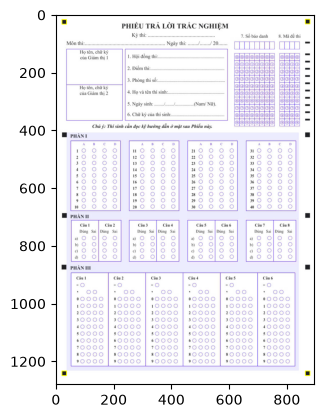

In [175]:
# draw rectangle to illustrate the result
for label,value in src_corners.items():
    bx,by,bw,bh = value['bbox']
    cv.rectangle(img_root, (bx, by), (bx + bw, by + bh), (255, 255, 0), 2)

plt.imshow(img_root)

In [176]:
warped_sheet.shape

(2545, 1800)

Successfully generated 160 bubble coordinates!


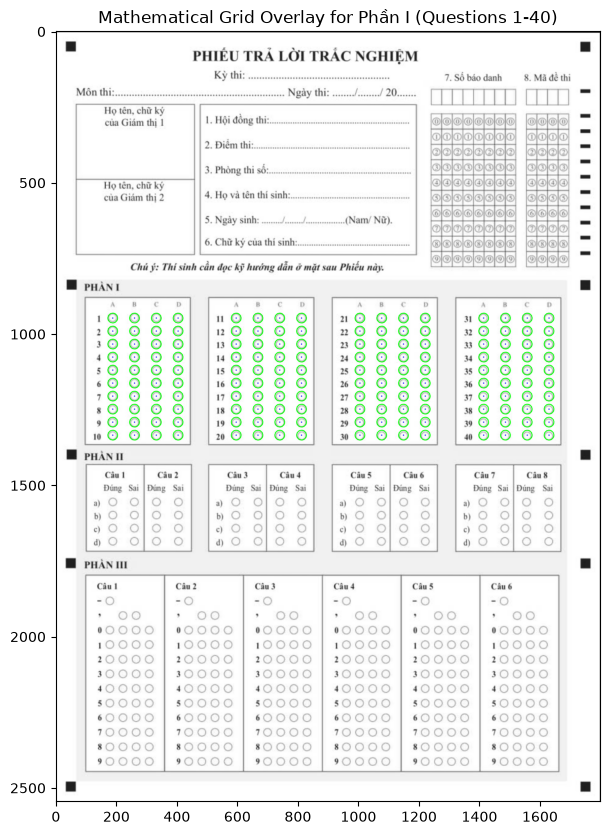

In [179]:
# 1. Grid Parameters
X_cols = [188, 596, 1005, 1414]  # X center of option 'A' for each column
Y_start = 947                    # Y center of the first row (Q1, Q11, Q21, Q31)
delta_x = 72                      # Horizontal distance between options A, B, C, D
delta_y = 43                      # Vertical distance between questions
bubble_radius = 16                # Radius of each bubble

options = ['A', 'B', 'C', 'D']
bubble_map = {}  # { (question_number, option_letter): (x, y, r) }

# 2. Mathematical Generation of all 160 bubbles
for col_idx in range(4):
    for row_idx in range(10):
        q_num = col_idx * 10 + row_idx + 1
        y = int(round(Y_start + row_idx * delta_y))
        
        for opt_idx in range(4):
            opt_letter = options[opt_idx]
            x = int(round(X_cols[col_idx] + opt_idx * delta_x))
            
            bubble_map[(q_num, opt_letter)] = (x, y, bubble_radius)

print(f"Successfully generated {len(bubble_map)} bubble coordinates!")

# 3. Visual Verification: Draw the calculated bubbles on warped_sheet
annotated = cv.cvtColor(warped_sheet, cv.COLOR_GRAY2BGR) if len(warped_sheet.shape) == 2 else warped_sheet.copy()

for (q, opt), (cx, cy, r) in bubble_map.items():
    # Green circle for bubble boundary
    cv.circle(annotated, (cx, cy), r, (0, 255, 0), 2)
    # Red dot for exact center
    cv.circle(annotated, (cx, cy), 2, (0, 0, 255), -1)

# Display Phần I region
plt.figure(figsize=(14, 10))
plt.imshow(annotated)
plt.title("Mathematical Grid Overlay for Phần I (Questions 1-40)")
plt.show()

In [180]:
bubble_map

{(1, 'A'): (188, 947, 16),
 (1, 'B'): (260, 947, 16),
 (1, 'C'): (332, 947, 16),
 (1, 'D'): (404, 947, 16),
 (2, 'A'): (188, 990, 16),
 (2, 'B'): (260, 990, 16),
 (2, 'C'): (332, 990, 16),
 (2, 'D'): (404, 990, 16),
 (3, 'A'): (188, 1033, 16),
 (3, 'B'): (260, 1033, 16),
 (3, 'C'): (332, 1033, 16),
 (3, 'D'): (404, 1033, 16),
 (4, 'A'): (188, 1076, 16),
 (4, 'B'): (260, 1076, 16),
 (4, 'C'): (332, 1076, 16),
 (4, 'D'): (404, 1076, 16),
 (5, 'A'): (188, 1119, 16),
 (5, 'B'): (260, 1119, 16),
 (5, 'C'): (332, 1119, 16),
 (5, 'D'): (404, 1119, 16),
 (6, 'A'): (188, 1162, 16),
 (6, 'B'): (260, 1162, 16),
 (6, 'C'): (332, 1162, 16),
 (6, 'D'): (404, 1162, 16),
 (7, 'A'): (188, 1205, 16),
 (7, 'B'): (260, 1205, 16),
 (7, 'C'): (332, 1205, 16),
 (7, 'D'): (404, 1205, 16),
 (8, 'A'): (188, 1248, 16),
 (8, 'B'): (260, 1248, 16),
 (8, 'C'): (332, 1248, 16),
 (8, 'D'): (404, 1248, 16),
 (9, 'A'): (188, 1291, 16),
 (9, 'B'): (260, 1291, 16),
 (9, 'C'): (332, 1291, 16),
 (9, 'D'): (404, 1291, 16),
